In [23]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Dataset downloaded!")
print("Path:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset downloaded!
Path: /kaggle/input/creditcardfraud


In [2]:
import os
files = os.listdir(path)
print("Files available:", files)

Files available: ['creditcard.csv']


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported!")

All libraries imported!


In [8]:

df = pd.read_csv(path + '/creditcard.csv')

print(" Dataset loaded!")
print("Shape:", df.shape)
print(df.head())

 Dataset loaded!
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010

Transaction counts:
Class
0    284315
1       492
Name: count, dtype: int64

0 = Legitimate
1 = Fraud


/tmp/ipykernel_609/110818105.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


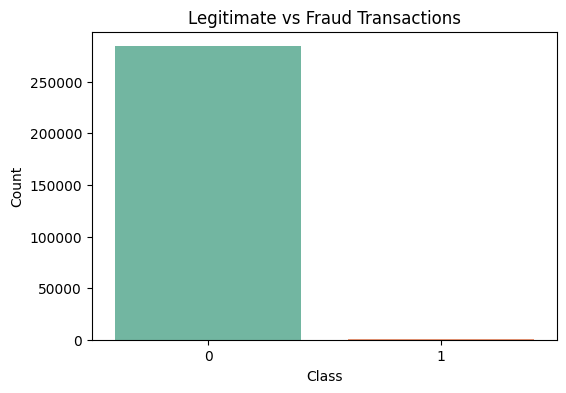

In [5]:

print("Transaction counts:")
print(df['Class'].value_counts())
print("\n0 = Legitimate")
print("1 = Fraud")
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title("Legitimate vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [16]:

fraud = df[df['Class'] == 1]
legitimate = df[df['Class'] == 0]

print("Fraud cases:", len(fraud))
print("Legitimate cases:", len(legitimate))
legitimate_sample = legitimate.sample(
    n=len(fraud), random_state=42)
balanced_df = pd.concat([fraud, legitimate_sample])

print("\nBalanced dataset size:", len(balanced_df))
print(balanced_df['Class'].value_counts())

Fraud cases: 492
Legitimate cases: 284315

Balanced dataset size: 984
Class
1    492
0    492
Name: count, dtype: int64


In [17]:
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Data split done!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split done!
Training samples: 787
Testing samples: 197


In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("All models trained!")
print(f"Logistic Regression Accuracy: {round(lr_acc*100, 2)}%")
print(f"Decision Tree Accuracy:       {round(dt_acc*100, 2)}%")
print(f"Random Forest Accuracy:       {round(rf_acc*100, 2)}%")

All models trained!
Logistic Regression Accuracy: 96.45%
Decision Tree Accuracy:       90.36%
Random Forest Accuracy:       95.94%


=== Random Forest Report ===
              precision    recall  f1-score   support

  Legitimate       0.92      1.00      0.96        98
       Fraud       1.00      0.92      0.96        99

    accuracy                           0.96       197
   macro avg       0.96      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197



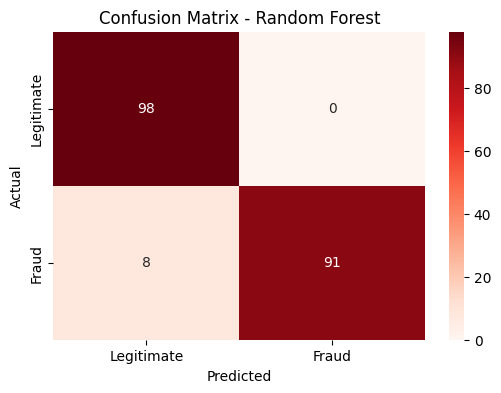

In [19]:
print("=== Random Forest Report ===")
print(classification_report(y_test, rf.predict(X_test),
      target_names=['Legitimate', 'Fraud']))
cm = confusion_matrix(y_test, rf.predict(X_test))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'],
            cmap='Reds')
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [22]:
def predict_fraud(transaction):
    # Fix: convert to DataFrame with correct column names
    transaction_df = pd.DataFrame(
        [transaction],
        columns=X.columns  # same columns as training data
    )
    prediction = rf.predict(transaction_df)
    probability = rf.predict_proba(transaction_df)

    if prediction[0] == 1:
        confidence = round(probability[0][1] * 100, 2)
        return f"FRAUDULENT Transaction! (Confidence: {confidence}%)"
    else:
        confidence = round(probability[0][0] * 100, 2)
        return f" LEGITIMATE Transaction (Confidence: {confidence}%)"

fraud_sample = fraud.drop('Class', axis=1).iloc[0].tolist()
legit_sample = legitimate.drop('Class', axis=1).iloc[0].tolist()


print("Test 1 (Fraud Transaction):")
print(predict_fraud(fraud_sample))

print("\nTest 2 (Legitimate Transaction):")
print(predict_fraud(legit_sample))


Test 1 (Fraud Transaction):
FRAUDULENT Transaction! (Confidence: 100.0%)

Test 2 (Legitimate Transaction):
 LEGITIMATE Transaction (Confidence: 94.0%)
